## Импорт библиотек

In [1]:
import pandas as pd
import string
import re
import nltk
import pymorphy3

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
df = pd.read_csv("petitions.csv")

In [3]:
df.head()

,id,public_petition_text,reason_category
0,3168490,снег на дороге,Благоустройство
1,3219678,очистить кабельный киоск от рекламы,Благоустройство
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД
4,3336285,Граффити,Благоустройство


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59889 entries, 0 to 59888
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    59889 non-null  int64 
 1   public_petition_text  59889 non-null  object
 2   reason_category       59889 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.4+ MB


## Предарительная обработка данных

In [5]:
def remove_punctuation(text): 
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text): 
    return ''.join([i if not i.isdigit() else ' ' for i in text])

def remove_multiple_spaces(text): 
    return re.sub(r'\s+', ' ', text, flags=re.I)

st = '❯\xa0—«»'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [6]:
df['prep_text'] = [remove_multiple_spaces(remove_numbers(remove_othersymbol(remove_punctuation(text.lower())))) for text in df['public_petition_text']]

In [7]:
df.head()

,id,public_petition_text,reason_category,prep_text
0,3168490,снег на дороге,Благоустройство,снег на дороге
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...
4,3336285,Граффити,Благоустройство,граффити


In [8]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','с','своём','всем','наш', 'свой']) 

In [9]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [10]:
df['tokenize_text'] = [tokenize(text) for text in df['prep_text']]

In [11]:
df.head()

,id,public_petition_text,reason_category,prep_text,tokenize_text
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...
4,3336285,Граффити,Благоустройство,граффити,граффити


In [12]:
stemmer = SnowballStemmer("russian")

stem_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = stemmer.stem(word)
            res.append(p)
        text = " ".join(res)
        stem_list.append(text)
    except Exception as e:
        print(e)
        
df['text_stem'] = stem_list

In [13]:
df.head()

,id,public_petition_text,reason_category,prep_text,tokenize_text,text_stem
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге,снег дорог
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы,очист кабельн киоск реклам
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...,прос убра дерев кустарник котор вышл предел га...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...,неудовлетворительн состоян парадн надпис двер ...
4,3336285,Граффити,Благоустройство,граффити,граффити,граффит


In [14]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [15]:
%%time
lemm_texts_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 2min 48s
Wall time: 2min 50s


In [16]:
df['text_lemm'] = [tokenize(text) for text in df['text_lemm']]

In [17]:
df.head()

,id,public_petition_text,reason_category,prep_text,tokenize_text,text_stem,text_lemm
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге,снег дорог,снег дорога
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы,очист кабельн киоск реклам,очистить кабельный киоск реклама
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...,прос убра дерев кустарник котор вышл предел га...,просить убрать дерево кустарник выйти предел г...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...,неудовлетворительн состоян парадн надпис двер ...,неудовлетворительный состояние парадный надпис...
4,3336285,Граффити,Благоустройство,граффити,граффити,граффит,граффити


In [18]:
# Получение текстовой строки из списка слов
from wordcloud import WordCloud

def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=russian_stopwords,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

In [19]:
corpus = get_corpus(df['reason_category'].values)

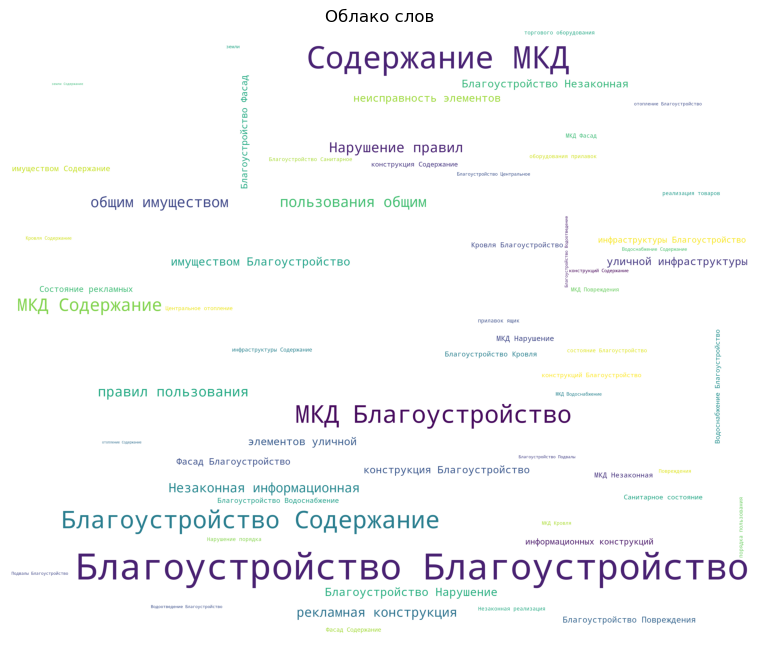

In [20]:
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.imshow(procWordCloud)
plt.axis('off')
plt.title('Облако слов')
plt.show()
plt.close(fig)

## Тематическое моделирование

In [21]:
vectorizer = CountVectorizer(analyzer='word', stop_words=russian_stopwords, ngram_range=(1, 3), min_df=2)
count_matrix = vectorizer.fit_transform(df['text_lemm'])

In [22]:
from sklearn.decomposition import TruncatedSVD

In [23]:
# создание модели LSA
lsa_model = TruncatedSVD(n_components=15, random_state=0)
lsa_model.fit(count_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(lsa_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ru, spb, spb ru, gov spb, gorod, gov, gorod gov spb, gorod gov, gov spb ru, ru problems
Topic 1: дом, тысяча, этаж, парадный, год, петербург, санкт, санкт петербург, просить, уборка
Topic 2: этаж, парадный, дом, уборка, дверь, просить, подъезд, мусор, лифт, фото
Topic 3: xx, xxxxxx, xxx, xxxxx, xxxxxxx, xxxxxxxx, xxxxxxxxx, xxxx, xxxxxxxxxx, xxxxxxxxxxx
Topic 4: дом, мусор, убрать, газон, территория, фасад, двор, снег, просить, площадка
Topic 5: мусор, уборка, убрать, график, газон, этаж, площадка, график уборка, производиться, влажный
Topic 6: дом, парадный, дверь, адрес, двор, просить, мусор, улица, ул, площадка
Topic 7: дверь, мусор, парадный, убрать, газон, входной, входной дверь, мусор газон, доводчик, просить
Topic 8: этаж, мусор, фасад, лифт, площадка, стена, здание, первый, освещение, тсж
Topic 9: парадный, дом, адрес, несанкционированный, объявление, надпись, парадный этаж, двор, освещение, фотофиксация
Topic 10: парадный, фасад, уборка, мусор, дверь, санкт, санкт пет

In [24]:
from sklearn.decomposition import NMF

In [25]:
# создание модели NMF
nmf_model = NMF(n_components=15, random_state=0)
nmf_model.fit(count_matrix)

# вывод топ слов для каждой темы
for i, topic in enumerate(nmf_model.components_):
    print(f"Topic {i}: {', '.join([vectorizer.get_feature_names_out()[i] for i in topic.argsort()[:-11:-1]])}")

Topic 0: ru, spb, spb ru, gov spb ru, gov spb, gov, gorod gov spb, gorod gov, gorod, problems
Topic 1: тысяча, петербург, санкт, санкт петербург, год, закон, административный, рубль, май, тысяча рубль
Topic 2: парадный, вход, парадный этаж, стена, ремонт, этаж парадный, состояние, адрес, вход парадный, номер
Topic 3: xx, xxxxxx, xxx, xxxxx, xxxxxxx, xxxxxxxx, xxxxxxxxx, xxxx, xxxxxxxxxx, xxxxxxxxxxx
Topic 4: дом, адрес, двор, улица, ул, сторона, дом адрес, проспект, пр, двор дом
Topic 5: мусор, газон, площадка, убрать, территория, мусор газон, убрать мусор, контейнерный, контейнер, контейнерный площадка
Topic 6: требоваться, работа, фотофиксация, прилагаться, фотофиксация прилагаться, произвести, требоваться произвести, произвести работа, несанкционированный, качественный
Topic 7: дверь, входной, подъезд, входной дверь, доводчик, закрываться, замок, состояние, дверь подъезд, дверь парадный
Topic 8: этаж, первый, лестница, подъезд, стена, первый этаж, лестничный, освещение, отсутствоват

## Векторизация текстовых данных

In [26]:
tfidf_vectorizer = TfidfVectorizer(max_df=1, max_features=10000000,
                                 min_df=1, stop_words=russian_stopwords,
                                 ngram_range=(1,3))

In [27]:
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_lemm'])

In [28]:
tfidf_matrix.shape

(59889, 441544)

## Классификация

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [30]:
X_train, X_test, y_train, y_test = train_test_split(tfidf_matrix, df['reason_category'], test_size=0.2, random_state=42)

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVC": LinearSVC(),
    "Random Forest": RandomForestClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name} Performance:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Logistic Regression Performance:
                                                                                  precision    recall  f1-score   support

                                                                 Благоустройство       0.58      1.00      0.74      6991
                                                                   Водоотведение       0.00      0.00      0.00        45
                                                                   Водоснабжение       0.00      0.00      0.00       169
                                                                          Кровля       0.00      0.00      0.00       183
                                  Нарушение порядка пользования общим имуществом       0.00      0.00      0.00        50
                                   Нарушение правил пользования общим имуществом       0.00      0.00      0.00       398
                         Незаконная информационная и (или) рекламная конструкция       0.00      0.00      0.00

In [33]:
import pickle

with open('model_rf.pkl', 'wb') as f:
    pickle.dump(models['Random Forest'], f)

In [34]:
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

## Парсинг

In [35]:
from bs4 import BeautifulSoup as bs
import requests
from selenium import webdriver as wd
from selenium.webdriver.edge.service import Service

In [36]:
path = 'msedgedriver.exe'

In [37]:
service = Service(path)
options = wd.EdgeOptions()
options.add_argument('--headless')
options.add_argument('--disable-blink-features=AutomationControlled')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
driver = wd.Edge(service = service, options=options)

In [38]:
url = 'https://vmeste.permkrai.ru/problem/reports?page=1'

In [39]:
driver.get(url)

In [40]:
soup = bs(driver.page_source, 'html.parser')

In [41]:
soup

<html lang="ru"><head><meta content="csrftoken" name="csrf-token-name"/>
<meta content="184c54e835c1074b215cc811f08f4699363cdf13acdf4597e9745e0cd917247cc868f8a1a12c6438" name="csrf-token-value"/>
<meta content="Ajax-Token" name="hmac-token-name"/>
<meta charset="utf-8"/>
<meta content="msMKxShsruxrtzfncBMCi1sSuHQX04jENS9jg1XK" id="csrf" name="csrf-token"/>
<script charset="utf-8" src="/649d0e0fe7008120c7149727.js?1750732043543"></script>
<script>
      window.appLocale = 'ru';
      window.appLocaleURL = '';
    </script>
<link href="https://vmeste.permkrai.ru/favicon.ico" rel="shortcut icon" type="image/x-icon"/>
<title>Сообщения жителей</title>
<link href="/build/app.css?v=a29aca9c2b9359547803" rel="stylesheet"/>
<script defer="" src="/build/runtime.js?v=cd78a093d3505f378abd"></script>
<script defer="" src="/build/vendors.js?v=395ee2bc85fafe32e79f"></script>
<script defer="" src="/build/app.js?v=2dad8f6a4ae5903003ab"></script>
<meta content="app-id=1458156281" name="apple-itunes-app"

In [42]:
with open('vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('model_rf.pkl', 'rb') as f:
    model = pickle.load(f)

In [43]:
pagenum = 1

for i in range(1,60):
    url = f'https://vmeste.permkrai.ru/problem/reports?page={pagenum}'
    print(f'страница {pagenum}')
    driver.get(url)
    soup = bs(driver.page_source, 'html.parser')
    problems = soup.find_all('div', class_='problem-report problem-reports__body')
    
    for problem in problems:
        problem_id = problem.find('a', class_='link problem-report__title')
        problem_category = problem.find('div', class_='problem-report__category-text')
        problem_text = problem.find('div', class_='problem-report__text')
        new_row = {"id": problem_id.text.split('№')[1], "public_petition_text": problem_text.text,
                  "reason_category": problem_category.text.split(' / ')[0]}
        df.loc[len(df)] = new_row
    pagenum += 1
driver.close()

страница 1
страница 2
страница 3
страница 4
страница 5
страница 6
страница 7
страница 8
страница 9
страница 10
страница 11
страница 12
страница 13
страница 14
страница 15
страница 16
страница 17
страница 18
страница 19
страница 20
страница 21
страница 22
страница 23
страница 24
страница 25
страница 26
страница 27
страница 28
страница 29
страница 30
страница 31
страница 32
страница 33
страница 34
страница 35
страница 36
страница 37
страница 38
страница 39
страница 40
страница 41
страница 42
страница 43
страница 44
страница 45
страница 46
страница 47
страница 48
страница 49
страница 50
страница 51
страница 52
страница 53
страница 54
страница 55
страница 56
страница 57
страница 58
страница 59


In [54]:
df

,id,public_petition_text,reason_category,prep_text,tokenize_text,text_stem,text_lemm
0,3168490,снег на дороге,Благоустройство,снег на дороге,снег дороге,снег дорог,снег дорога
1,3219678,очистить кабельный киоск от рекламы,Благоустройство,очистить кабельный киоск от рекламы,очистить кабельный киоск рекламы,очист кабельн киоск реклам,очистить кабельный киоск реклама
2,2963920,"Просим убрать все деревья и кустарники, которы...",Благоустройство,просим убрать все деревья и кустарники которые...,просим убрать деревья кустарники которые вышли...,прос убра дерев кустарник котор вышл предел га...,просить убрать дерево кустарник выйти предел г...
3,3374910,Неудовлетворительное состояние парадной - надп...,Содержание МКД,неудовлетворительное состояние парадной надпис...,неудовлетворительное состояние парадной надпис...,неудовлетворительн состоян парадн надпис двер ...,неудовлетворительный состояние парадный надпис...
4,3336285,Граффити,Благоустройство,граффити,граффити,граффит,граффити
...,...,...,...,...,...,...,...
60474,728016,Незаконная расклейка объявлений на опоре ВЛ 11...,Рекламные конструкции,незаконная расклейка объявлений на опоре вл кв...,незаконная расклейка объявлений опоре вл кв ко...,незакон расклейк объявлен опор вл кв координат,NaN
60475,728015,Незаконная расклейка объявлений на светофорной...,Рекламные конструкции,незаконная расклейка объявлений на светофорной...,незаконная расклейка объявлений светофорной ст...,незакон расклейк объявлен светофорн стойк коор...,NaN
60476,728014,Незаконная расклейка объявлений. Координаты 57...,Рекламные конструкции,незаконная расклейка объявлений координаты,незаконная расклейка объявлений координаты,незакон расклейк объявлен координат,NaN
60477,728013,Незаконная расклейка объявлений на фасаде. Коо...,Рекламные конструкции,незаконная расклейка объявлений на фасаде коор...,незаконная расклейка объявлений фасаде координаты,незакон расклейк объявлен фасад координат,NaN


In [57]:
%%time
lemm_texts_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

df['text_lemm'] = [tokenize(text) for text in df['text_lemm']]

CPU times: total: 1min 20s
Wall time: 1min 21s


In [58]:
X_train = tfidf.fit_transform(df['text_lemm'])
y_train = df['reason_category']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

with open(f'updated_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'updated_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)